In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Model parameters
beta = 0.9       # Discount factor
gamma = 4.0      # Absolute risk aversion
sigma = 0.16     # Volatility of risky return shock
mu = 0.04        # Expected excess return
w = 1.0          # Initial wealth
Rf = 1.0         # Risk-free return

# Possible shock realizations (eta) and associated probabilities
etas = np.array([-np.sqrt(3), 0, np.sqrt(3)])
probs = np.array([1/6, 2/3, 1/6])

In [2]:
# Part 1 — Expected return and risk premium

# Risky return realizations
returns = Rf + mu + sigma * etas

# Expected gross risky return E[R] = sum(prob_i * R_i)
ER = np.sum(probs * returns)

# Variance of risky return Var[R] = sum(prob_i * (R_i - E[R])^2)
Var_R = np.sum(probs * (returns - ER)**2)

# Standard deviation of risky return
std_R = np.sqrt(Var_R)

# Sharpe ratio = (E[R] - Rf) / std_R
Sharpe_ratio = (ER - Rf) / std_R

print(f"Expected gross risky return: {ER:.5f}")
print(f"Variance of the risky return: {Var_R:.5f}")
print(f'Standard deviation of the risky return: {std_R:.5f}')
print(f'Risk premium: {ER - Rf:.5f}')
print(f'Sharpe ratio: {Sharpe_ratio:.5f}')

Expected gross risky return: 1.04000
Variance of the risky return: 0.02560
Standard deviation of the risky return: 0.16000
Risk premium: 0.04000
Sharpe ratio: 0.25000


In [3]:
# Part 2 — Utility function

def util(c, gamma):
    """
    Return the flow utility of consumption for a given risk aversion.

    Parameters
    ----------
    c : float or array
        Consumption level.
    gamma : float
        Risk aversion parameter.

    Returns
    -------
    u : float or array
        Utility value.
    """
    u = -np.exp(-gamma * c)
    return u

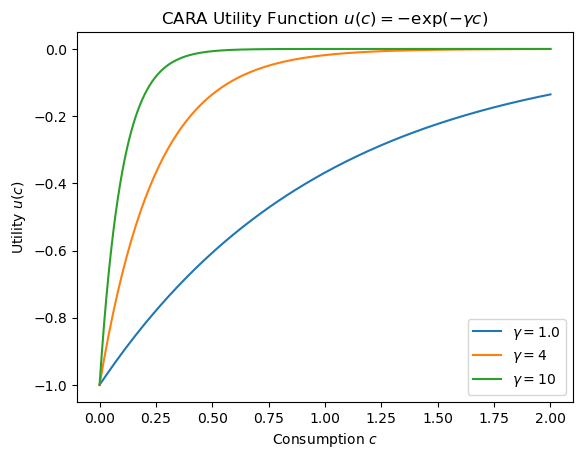

In [4]:
# Plot utility function
c_grid = np.linspace(0, 2, 200)

for gam in [1.0, 4, 10]:
    plt.plot(c_grid, util(c_grid, gamma=gam), label=rf'$\gamma={gam}$')

plt.xlabel('Consumption $c$')
plt.ylabel('Utility $u(c)$')
plt.title(r'CARA Utility Function $u(c) = -\exp(-\gamma c)$')
plt.legend()

In [5]:
# Part 3 — Expected utility function

def expected_util(s, alpha, beta, gamma, sigma, mu, w, etas, probs):
    """
    Calculate the expected lifetime utility for given parameters.

    Parameters
    ----------
    s : float or array
        Savings in period 1.
    alpha : float or array
        Fraction of savings invested in the risky asset.
    beta : float
        Discount factor for future utility.
    gamma : float
        Absolute risk aversion parameter.
    sigma : float
        Volatility of the risky return shock.
    mu : float
        Expected excess return of the risky asset.
    w : float
        Initial wealth in period 1.
    etas : array
        Array of shock realizations.
    probs : array
        Array of probabilities of shock realizations.

    Returns
    -------
    U : float or array
        Expected lifetime utility.
    """
    # Risk-free return
    Rf = 1.0

    # Deterministic wealth component independent of risky return
    const = Rf * (1.0 - alpha) * s

    # Expected utility in period 2
    Eu2 = 0.0
    for i, (prob, eta) in enumerate(zip(probs, etas)):
        R_i = Rf + mu + sigma * eta
        c2_i = R_i * alpha * s + const
        Eu2 += prob * util(c2_i, gamma)

    # Consumption in period 1
    c1 = w - s

    # Utility in period 1
    u1 = util(c1, gamma)

    # Expected lifetime utility
    U = u1 + beta * Eu2

    return U

In [6]:
# Part 4 — Visualization of expected utility

# Candidate grid for risky shares
alpha_grid = np.array((0.0, 0.5, 1.0))

# Candidate grid for savings levels
s_grid = np.linspace(0.1, w-0.1, 200)

# Array to store expected lifetime utility
U = np.empty((len(alpha_grid), len(s_grid)))

# Iterate over alphas, compute expected utility for each savings level
for i, alpha in enumerate(alpha_grid):
    U[i] = expected_util(s_grid, alpha, beta, gamma, sigma, mu, w, etas, probs)

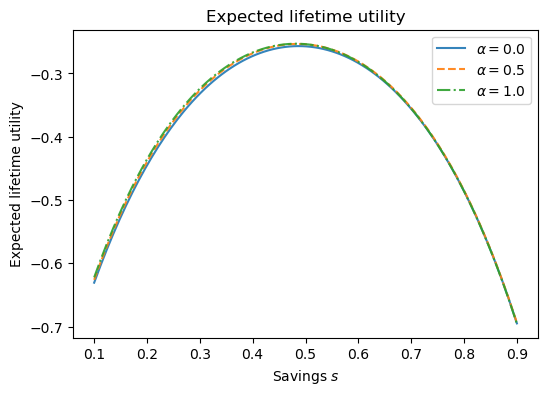

In [7]:
# Plot expected lifetime utility
fig, ax = plt.subplots(figsize=(6, 4))
linestyles = ['-', '--', '-.']

for i, alpha in enumerate(alpha_grid):
    ax.plot(s_grid, U[i], ls=linestyles[i], alpha=0.9, label=fr'$\alpha = {alpha}$')

ax.set_xlabel('Savings $s$')
ax.set_ylabel('Expected lifetime utility')
ax.set_title('Expected lifetime utility')
ax.legend()
plt.show()

In [8]:
# Part 5 — Optimization using grid search

def find_optimum(beta, gamma, sigma, mu, w, etas, probs):
    """
    Find the optimal savings level and risky share to maximize expected utility.

    Parameters
    ----------
    beta : float
        Discount factor.
    gamma : float
        Absolute risk aversion coefficient.
    sigma : float
        Volatility of the risky return shock.
    mu : float
        Expected excess return of the risky asset.
    w : float
        Initial wealth.
    etas : array
        Shock realizations.
    probs : array
        Probabilities of shock realizations.

    Returns
    -------
    s_opt : float
        Optimal savings level.
    alpha_opt : float
        Optimal fraction of savings invested in the risky asset.
    U_max : float
        Maximum expected utility.
    """
    # Candidate grid for savings levels
    s_grid = np.linspace(1e-6, w-1e-6, 1000)

    # Candidate grid for risky shares
    alpha_grid = np.linspace(0, 1, 1000)

    s_opt = None
    alpha_opt = None
    U_max = -np.inf

    # Iterate over candidate savings levels, find optimal risky share for each
    for s in s_grid:
        U_grid = expected_util(s, alpha_grid, beta, gamma, sigma, mu, w, etas, probs)
        imax = np.argmax(U_grid)
        if U_grid[imax] > U_max:
            s_opt = s
            alpha_opt = alpha_grid[imax]
            U_max = U_grid[imax]

    return s_opt, alpha_opt, U_max

In [9]:
# Part 6 — Optimal savings and portfolio

s_opt, alpha_opt, U_max = find_optimum(beta, gamma, sigma, mu, w, etas, probs)

print(f'Optimal savings: {s_opt:.4f}')
print(f'Optimal risky share: {alpha_opt:.4f}')
print(f'Value of expected lifetime utility: {U_max:.4f}')

Optimal savings: 0.4825
Optimal risky share: 0.8098
Value of expected lifetime utility: -0.2528


In [10]:
# Part 7 — Sensitivity to risk aversion

# Risk aversion values for which to compute risky share
gamma_grid = np.linspace(1.0, 10.0, 101)

# Array to store optimal risky shares for each risk aversion
alpha_opt_grid = np.empty_like(gamma_grid)

for i, gam in enumerate(gamma_grid):
    # Find optimal choices for given risk aversion
    s_opt, alpha_opt, _ = find_optimum(beta, gam, sigma, mu, w, etas, probs)
    # Store optimal risky share
    alpha_opt_grid[i] = alpha_opt

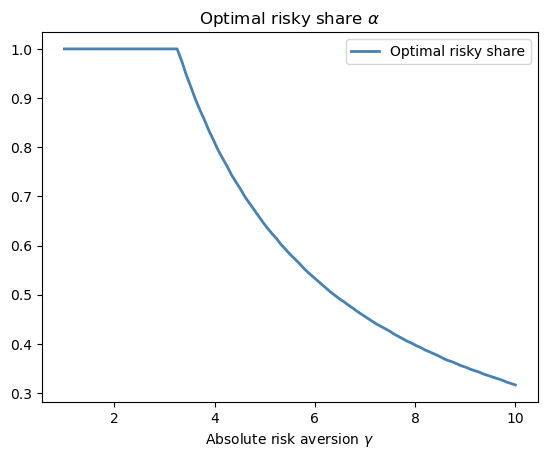

In [11]:
# Plot optimal risky share vs risk aversion
plt.plot(gamma_grid, alpha_opt_grid, c='steelblue', lw=2.0, label='Optimal risky share')
plt.xlabel(r'Absolute risk aversion $\gamma$')
plt.title(r'Optimal risky share $\alpha$')
plt.legend()
plt.show()

In [12]:
# Part 8 — Sensitivity to return volatility

# Volatility parameters for which to compute risky share
sigma_grid = np.linspace(0.01, 0.5, 101)

# Array to store optimal risky shares for each sigma
alpha_opt_grid = np.empty_like(sigma_grid)

for i, sig in enumerate(sigma_grid):
    # Find optimal choices for given sigma
    s_opt, alpha_opt, _ = find_optimum(beta, gamma, sig, mu, w, etas, probs)
    # Store optimal risky share
    alpha_opt_grid[i] = alpha_opt

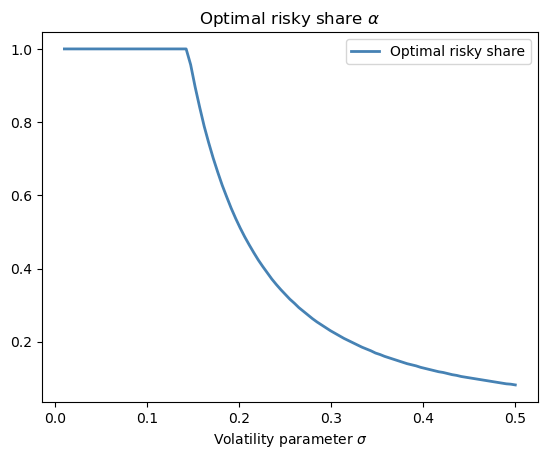

In [13]:
# Plot optimal risky share vs volatility
plt.plot(sigma_grid, alpha_opt_grid, c='steelblue', lw=2.0, label='Optimal risky share')
plt.xlabel(r'Volatility parameter $\sigma$')
plt.title(r'Optimal risky share $\alpha$')
plt.legend()
plt.show()